In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

# 1
## 1.1

In [ ]:
# Load data, shape: (256 samples, 10 channels, 300 trials)
mat = loadmat('responses.mat')
responses = mat['responses']

# Calculate time vector for 256 Hz sampling rate
fs = 256
n_samples = responses.shape[0]
t = np.arange(n_samples) / fs

# Electrode labels
electrodes = {0: 'Fz', 1: 'C4', 2: 'Cz', 3: 'C3', 4: 'P4', 5: 'Pz', 6: 'P3', 7: 'PO8', 8: 'Oz', 9: 'PO7'}

## 1.2

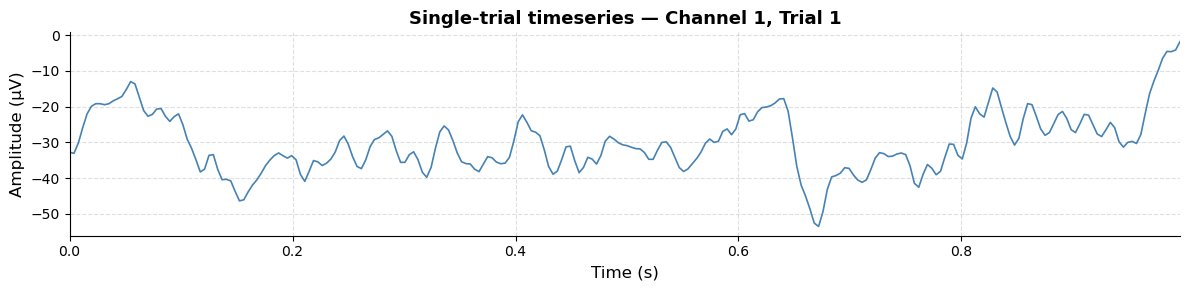

In [ ]:
fig, ax = plt.subplots(figsize=(12, 3))
# Plot the response of the first channel  of the first trial
ax.plot(t, responses[:, 0, 0], color='steelblue', linewidth=1.2)
ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Amplitude (µV)', fontsize=12)
ax.set_title('Single-trial timeseries — Channel 1, Trial 1', fontsize=13, fontweight='bold')
ax.set_xlim(t[0], t[-1])
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 1.2

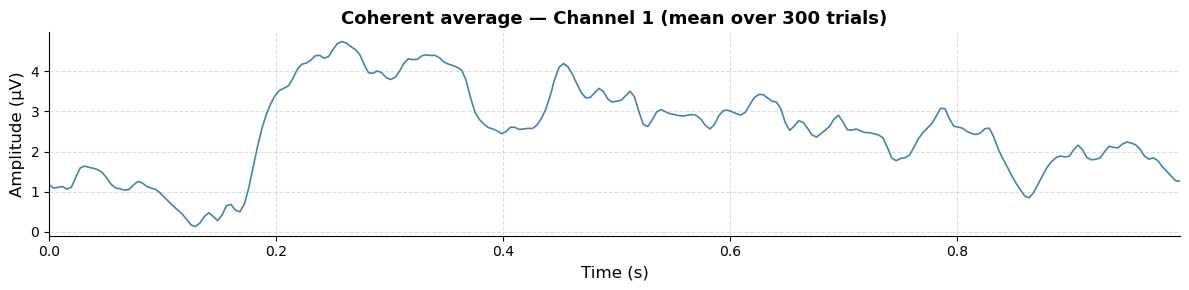

In [ ]:
fig, ax = plt.subplots(figsize=(12, 3))
# Plot the mean of the responses across trials
ax.plot(t, responses[:, 0, :].mean(axis=1), color='steelblue', linewidth=1.2)
ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Amplitude (µV)', fontsize=12)
ax.set_title('Coherent average — Channel 1 (mean over 300 trials)', fontsize=13, fontweight='bold')
ax.set_xlim(t[0], t[-1])
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# 2
## 2.1

In [ ]:
import numpy.fft as fft

def power_spectrum(signal, fs):
    """
    Hamming-windowed, single-sided power spectrum of a 1D signal segment.
    """
    n = len(signal)
    # Hamming windowing
    window = np.hamming(n) * signal
    # Get coefficients & frequencies
    coeffs = fft.rfft(window)
    freqs = fft.rfftfreq(n, d=1/fs)
    # Returns frequencies and single-sided power spectrum
    return freqs, np.abs(coeffs)

In [ ]:
# Coherent average across trials: (256, 10)
avg = responses.mean(axis=2)

# Compute power spectrum per channel
freqs, _ = power_spectrum(avg[:, 0], fs)
power = np.stack([power_spectrum(avg[:, ch], fs)[1] for ch in range(avg.shape[1])], axis=1)

## 2.2 - 2.3

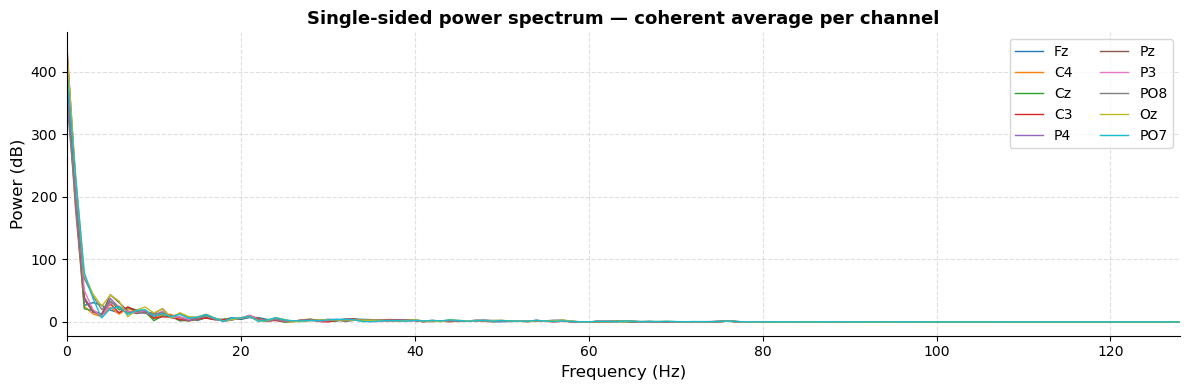

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))

# Plot power spectrum for all channels
for ch in range(power.shape[1]):
    ax.plot(freqs, power[:, ch], linewidth=1.0, label=electrodes[ch])

ax.set_xlabel("Frequency (Hz)", fontsize=12)
ax.set_ylabel("Power (dB)", fontsize=12)
ax.set_title("Single-sided power spectrum — coherent average per channel", fontsize=13, fontweight="bold")
ax.set_xlim(0, freqs[-1])
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(ncol=2, fontsize=10)
plt.tight_layout()
plt.show()


# 3
## 3.1 - 3.4

In [ ]:
# Sliding window length and step size
win_size = 64
step_size = 8

# Windows, frequency bins
starts = range(0, avg.shape[0] - win_size + 1, step_size)
freqs_stft, _ = power_spectrum(avg[:win_size, 0], fs)

# Spectrogram for all channels, shape: (n_steps, n_freqs, n_channels)
spectrogram = np.stack([
    np.array([power_spectrum(avg[s:s + win_size, ch], fs)[1] for s in starts])
    for ch in range(avg.shape[1])
], axis=2)

# Time vector, at the midpoints of the windows
t_steps = np.array([s + win_size / 2 for s in starts]) / fs

## 3.5-3.6

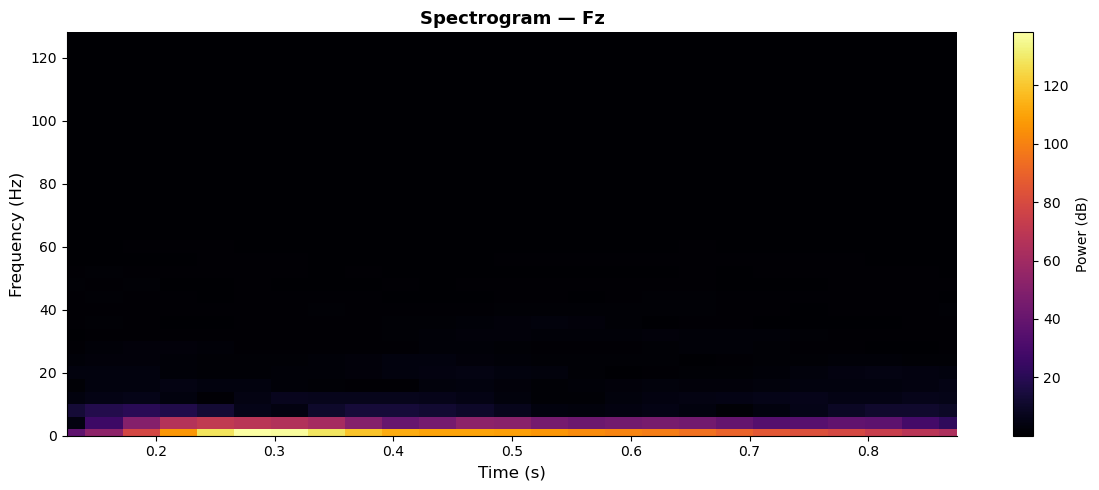

In [ ]:
# Channels: 0=Fz, 1=C4, 2=Cz, 3=C3, 4=P4, 5=Pz, 6=P3, 7=PO8, 8=Oz, 9=PO7
ch = 0

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.pcolormesh(t_steps, freqs_stft, spectrogram[:, :, ch].T,
                   shading="auto", cmap="inferno")
fig.colorbar(im, ax=ax, label="Power (dB)")
ax.set_xlabel("Time (s)", fontsize=12)
ax.set_ylabel("Frequency (Hz)", fontsize=12)
ax.set_title(f"Spectrogram — {electrodes[ch]}", fontsize=13, fontweight="bold")
ax.set_xlim(t_steps[0], t_steps[-1])
ax.set_ylim(0, freqs_stft[-1])
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# 4
## 4.1

In [ ]:
# Per (step, channel) peak, average if several frequencies tie
max_vals = spectrogram.max(axis=1, keepdims=True)
mask = (spectrogram == max_vals)
band_power = (spectrogram * mask).sum(axis=1) / mask.sum(axis=1)

## 4.2

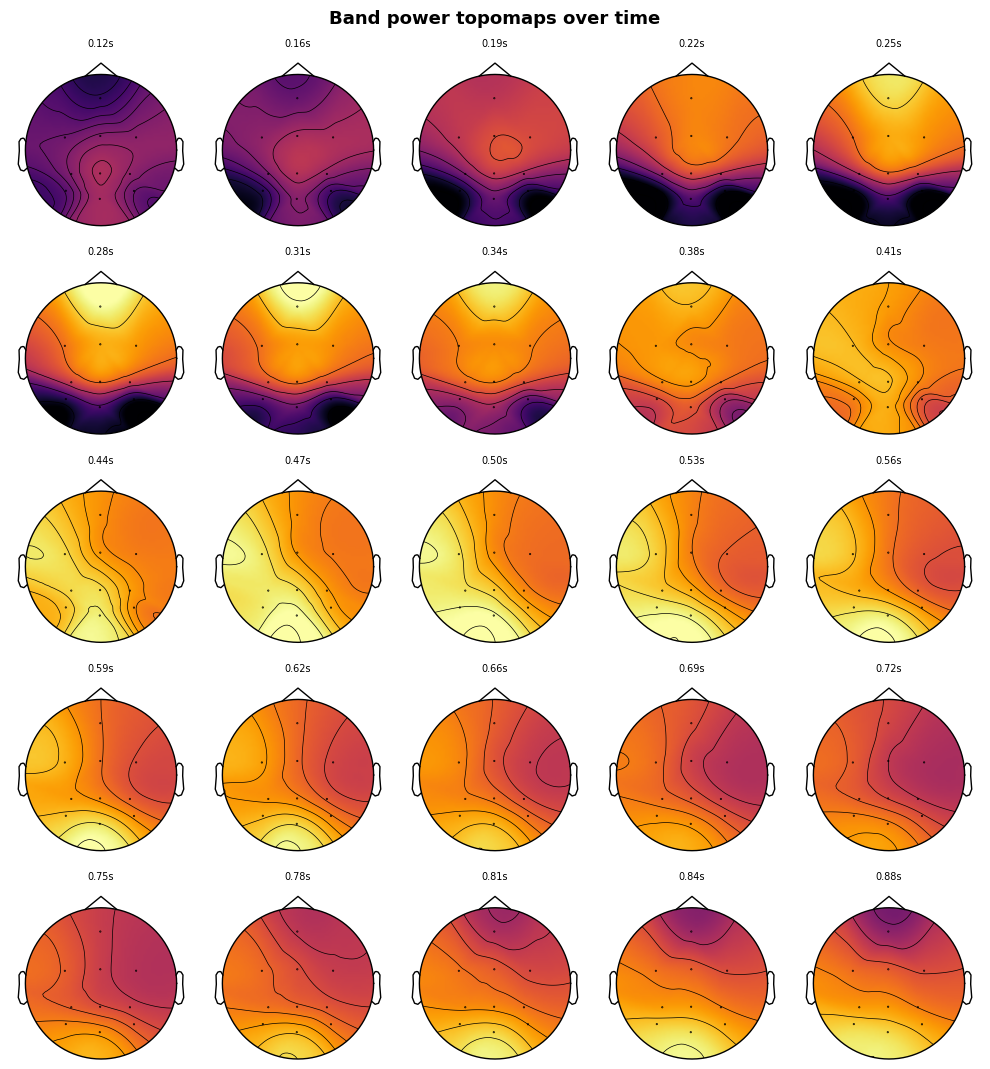

In [ ]:
import mne

info = mne.create_info(
    ch_names=list(electrodes.values()),
    ch_types="eeg",
    sfreq=fs
)
info.set_montage("standard_1020")

n_steps =  band_power.shape[0]
ncols = nrows = 5

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2, nrows * 2.2))
axes = axes.flatten()

vmin, vmax = band_power.min(), band_power.max()
for i in range(n_steps):
    mne.viz.plot_topomap(
        band_power[i],
        info,
        axes=axes[i],
        show=False,
        vlim=(vmin, vmax),
        cmap="inferno"
    )
    axes[i].set_title(f"{t_steps[i]:.2f}s", fontsize=7)

for ax in axes[n_steps:]:
    ax.set_visible(False)

fig.suptitle("Band power topomaps over time", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# 5
## 5.1

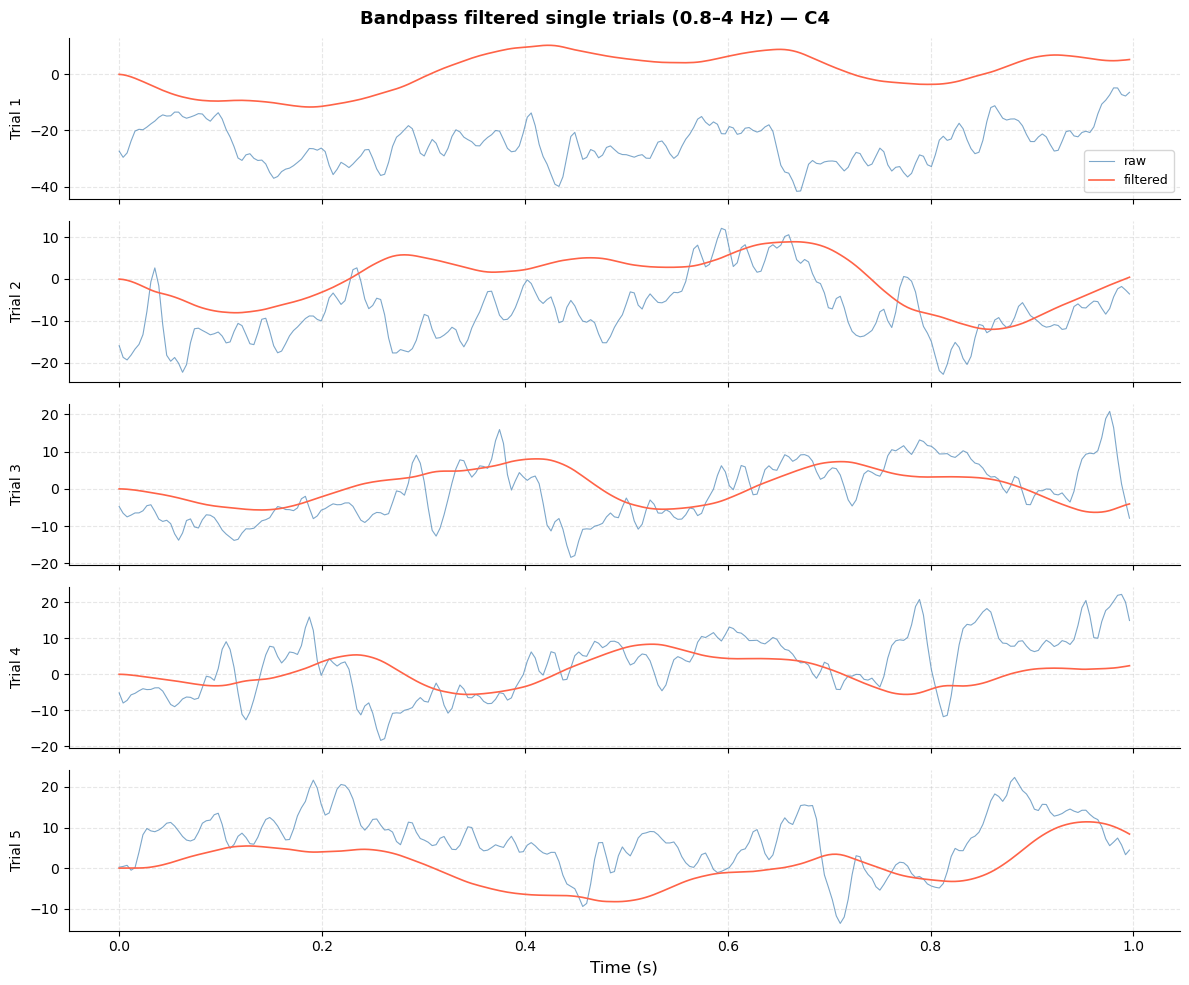

In [ ]:
from scipy.signal import butter, lfilter

# Butterworth bandpass filter, 0.8 - 4 Hz
b, a = butter(N=2, Wn=[0.8, 4.0], btype="bandpass", fs=fs) # type: ignore

# Apply filter along time axis
responses_filt = lfilter(b, a, responses, axis=0)

ch = 1
n_trials_plot = 5

fig, axes = plt.subplots(n_trials_plot, 1, figsize=(12, n_trials_plot * 2), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(t, responses[:, ch, i], color="steelblue", linewidth=0.8, alpha=0.7, label="raw")
    ax.plot(t, responses_filt[:, ch, i], color="tomato", linewidth=1.2, label="filtered")
    ax.set_ylabel(f"Trial {i+1}", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(True, linestyle="--", alpha=0.3)

axes[0].legend(fontsize=9)
axes[-1].set_xlabel("Time (s)", fontsize=12)
fig.suptitle(f"Bandpass filtered single trials (0.8–4 Hz) — {electrodes[ch]}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 5.2

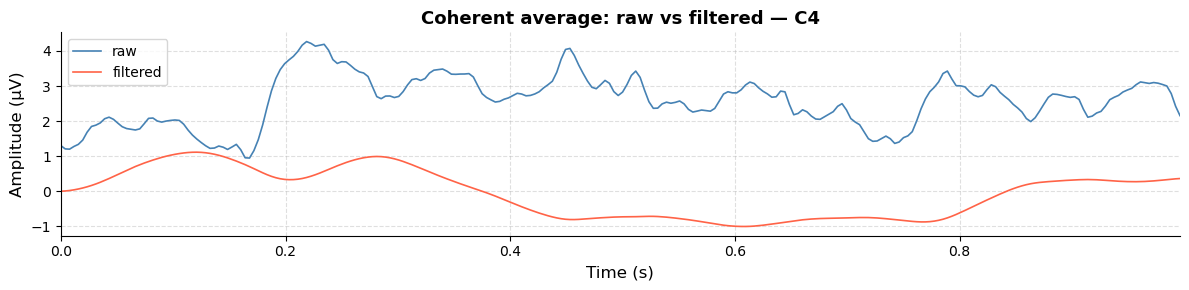

In [ ]:
fig, ax = plt.subplots(figsize=(12, 3))
# Coherent average across channel dimension
ax.plot(t, responses[:, ch, :].mean(axis=1), color="steelblue", linewidth=1.2, label="raw")
ax.plot(t, responses_filt[:, ch, :].mean(axis=1), color="tomato", linewidth=1.2, label="filtered")
ax.set_xlabel("Time (s)", fontsize=12)
ax.set_ylabel("Amplitude (µV)", fontsize=12)
ax.set_title(f"Coherent average: raw vs filtered — {electrodes[ch]}", fontsize=13, fontweight="bold")
ax.set_xlim(t[0], t[-1])
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# 6
## 6.1

In [ ]:
# Load ongoing EEG (no stimulus): shape (256, 10, 1500)
mat2 = loadmat('ongoingEEG.mat')
ongoing = mat2['ongoingEEG']

# One-sided power spectrum per trial per channel for both conditions
freqs_trials, _ = power_spectrum(responses[:, 0, 0], fs)
n_freqs = len(freqs_trials)

def trials_power(data):
    n_ch, n_t = data.shape[1], data.shape[2]
    out = np.zeros((n_freqs, n_ch, n_t))
    for ch in range(n_ch):
        for tr in range(n_t):
            _, out[:, ch, tr] = power_spectrum(data[:, ch, tr], fs)
    return out

# Concatenate conditions: (n_freqs, 10, 1800)
power_all = np.concatenate([trials_power(responses), trials_power(ongoing)], axis=2)

# Label vector: 1 = stimulus, 0 = ongoing, shape (1800, 1)
labels = np.concatenate([np.ones(responses.shape[2]), np.zeros(ongoing.shape[2])]).reshape(-1, 1)

# correlation per (frequency, channel)
y = labels.flatten()
X = power_all.reshape(-1, power_all.shape[2])
r = np.corrcoef(X, y)[-1, :-1]
r2 = r.reshape(n_freqs, len(electrodes)) ** 2


## 6.2

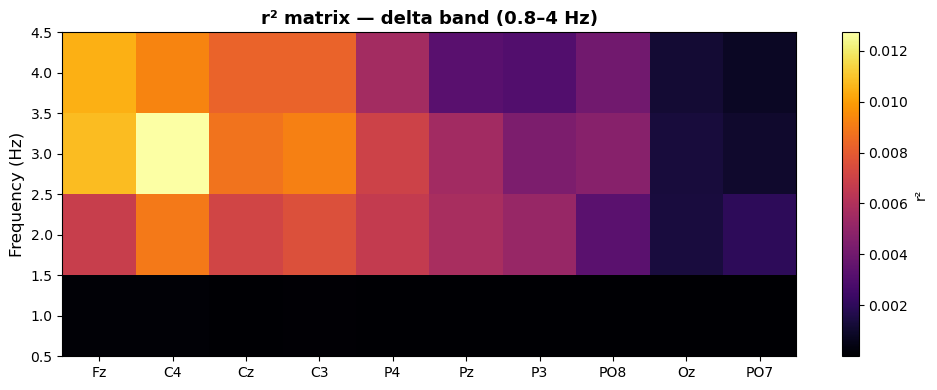

In [ ]:
# Frequency mask to 0.8 – 4 Hz
freq_mask = (freqs_trials >= 0.8) & (freqs_trials <= 4.0)
r2_band = r2[freq_mask, :]

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.pcolormesh(np.arange(len(electrodes)), freqs_trials[freq_mask], r2_band,
                   shading="auto", cmap="inferno")
fig.colorbar(im, ax=ax, label="r²")
ax.set_xticks(np.arange(len(electrodes)))
ax.set_xticklabels(list(electrodes.values()), fontsize=10)
ax.set_ylabel("Frequency (Hz)", fontsize=12)
ax.set_title("r² matrix — delta band (0.8–4 Hz)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 6.3

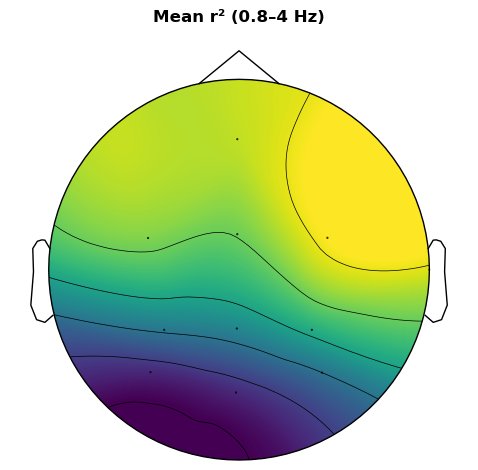

In [ ]:
# Mean correlation
r2_mean = r2[freq_mask, :].mean(axis=0)

fig, ax = plt.subplots()
mne.viz.plot_topomap(r2_mean, info, axes=ax, show=False, cmap="viridis")
ax.set_title("Mean r² (0.8–4 Hz)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


## 6.4

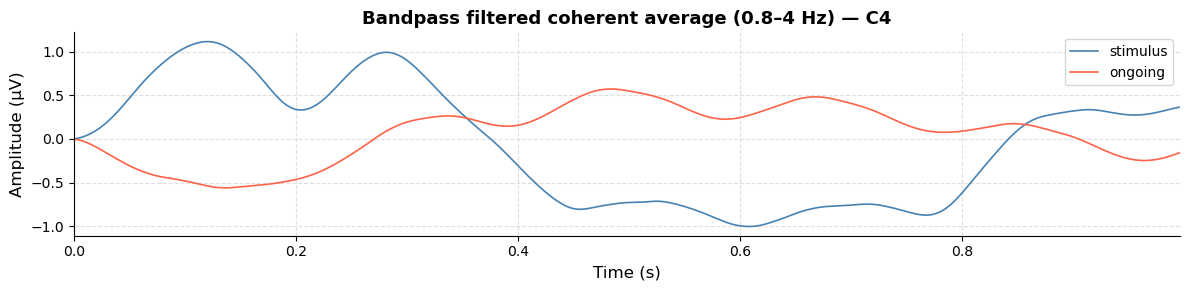

In [ ]:
# Filter ongoing EEG with same Butterworth bandpass (0.8–4 Hz)
ongoing_filt = lfilter(b, a, ongoing, axis=0)

# Coherent average of filtered signals on best channel
best_ch = int(np.argmax(r2_mean))
stim_avg_filt    = responses_filt[:, best_ch, :].mean(axis=1)
ongoing_avg_filt = ongoing_filt[:, best_ch, :].mean(axis=1)

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t, stim_avg_filt,    color="steelblue", linewidth=1.2, label="stimulus")
ax.plot(t, ongoing_avg_filt, color="tomato",    linewidth=1.2, label="ongoing")
ax.set_xlabel("Time (s)", fontsize=12)
ax.set_ylabel("Amplitude (µV)", fontsize=12)
ax.set_title(f"Bandpass filtered coherent average (0.8–4 Hz) — {electrodes[best_ch]}", fontsize=13, fontweight="bold")
ax.set_xlim(t[0], t[-1])
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()
